**Imports**

#**Building Markov Transition Matrix **

A first-order Markov model describes the probability of a nucleotide following another. For DNA, you build a 4x4 matrix showing transition probabilities between A, C, G, T.

**Read the Input DNA Sequence**             
Load a DNA sequence from a FASTA or plain text file. Ensure the sequence is uppercase and contains only A, C, G, T.

In [18]:
# Example: loading sequence from a file (or hardcoding for testing)
with open("multiline_input.fasta", "r") as f:
    sequence = f.read().replace("\n", "").strip().upper()

# Filter to only ACGT
sequence = ''.join([base for base in sequence if base in 'ACGT'])

print("Sequence Length:", len(sequence))
print("First 100 bases:", sequence[:100])


Sequence Length: 12398
First 100 bases: TCCAATTGAGCTATACCGTCAGAAGTAGATGAGATCTAACGGCGCGCCCGGTTGTCGCAGCCACGCTAGGCACAGTCAAAGCAGTGACCCAGCCCTTCAG


**Initialize the Transition Count Matrix **                                
Create a 4×4 matrix where matrix[i][j] counts how often nucleotide j follows i.

In [19]:
import numpy as np

# Define nucleotide order and mapping
nucleotides = ['A', 'C', 'G', 'T']
index = {nuc: i for i, nuc in enumerate(nucleotides)}

# Initialize count matrix (4x4)
count_matrix = np.zeros((4, 4), dtype=int)



**Populate the Count Matrix**

Loop through the sequence and update the matrix based on observed transitions.


In [20]:
# Count transitions
for i in range(len(sequence) - 1):
    current = sequence[i]
    next_ = sequence[i + 1]
    count_matrix[index[current], index[next_]] += 1

# Show raw counts
print("Transition Count Matrix:")
print(pd.DataFrame(count_matrix, index=nucleotides, columns=nucleotides))

Transition Count Matrix:
     A    C    G    T
A  793  767  837  764
C  750  774  745  773
G  793  779  805  772
T  825  723  762  735


**Normalize to Get Transition Probabilities **                             
Convert counts to probabilities by dividing each row by the row's total (i.e., sum of transitions from a base).

In [23]:
# Avoid division by zero
row_sums = count_matrix.sum(axis=1, keepdims=True)
transition_matrix = count_matrix / row_sums

# Convert to DataFrame for readability
transition_df = pd.DataFrame(transition_matrix, index=nucleotides, columns=nucleotides)

print("Transition Probability Matrix:")
print(transition_df.round(4))


Transition Probability Matrix:
        A       C       G       T
A  0.2509  0.2426  0.2648  0.2417
C  0.2465  0.2544  0.2449  0.2541
G  0.2518  0.2474  0.2556  0.2452
T  0.2709  0.2374  0.2502  0.2414


**Visualize the Matrix as a Heatmap**

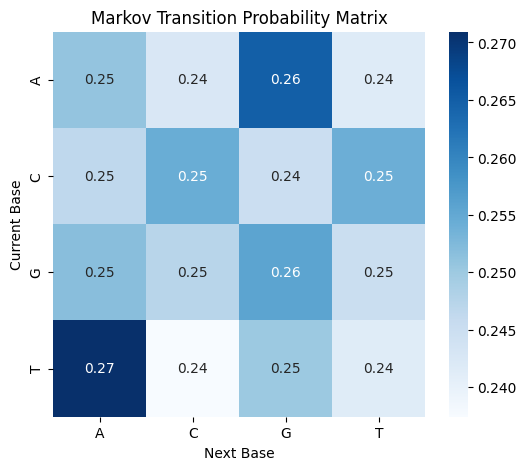

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.heatmap(transition_df, annot=True, cmap="Blues", fmt=".2f")
plt.title("Markov Transition Probability Matrix")
plt.ylabel("Current Base")
plt.xlabel("Next Base")
plt.show()
